# Model 2: XGBoost

Gradient-boosted tree model predicting concentration-driven portfolio risk, compared against Model 1 (Logistic Regression) as a more complex, tree-based alternative.

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import joblib
import os

## Configuration and Data Load

Uses the same `model_features.csv` and identical time-based train/test split as Model 1, ensuring a fair, directly comparable evaluation.

In [2]:
PROCESSED_DATA_DIR = "../../data/processed"
ARTIFACTS_DIR = "../../artifacts"
REPORTS_DIR = "../../reports"

model_data = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "model_features.csv"))

quarter_order = ["2015-03", "2015-06", "2015-09", "2015-12",
                  "2016-03", "2016-06", "2016-09", "2016-12",
                  "2017-03", "2017-06"]

train_quarters = quarter_order[:-2]
test_quarters = quarter_order[-2:]

train_df = model_data[model_data["quarter"].isin(train_quarters)].copy()
test_df = model_data[model_data["quarter"].isin(test_quarters)].copy()

feature_cols = ["hhi", "top_holding_pct", "num_holdings", "sector_hhi", "total_value"]
X_train, y_train = train_df[feature_cols], train_df["label"]
X_test, y_test = test_df[feature_cols], test_df["label"]

print(f"Train: {len(X_train)} rows, {y_train.mean():.1%} positive")
print(f"Test: {len(X_test)} rows, {y_test.mean():.1%} positive")

Train: 15151 rows, 4.8% positive
Test: 5093 rows, 2.2% positive


## Baseline Model (Untuned)

No feature scaling is required, tree-based models split on raw feature values and are insensitive to scale. `scale_pos_weight` compensates for label imbalance, XGBoost's standard mechanism for this, analogous to Logistic Regression's `class_weight="balanced"`.

In [3]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.1f}")

model2 = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)
model2.fit(X_train, y_train)

print("Model fitted.")

scale_pos_weight: 19.7
Model fitted.


Baseline feature importance and test-set performance, shown below, are the comparison point for the hyperparameter tuning investigation that follows.

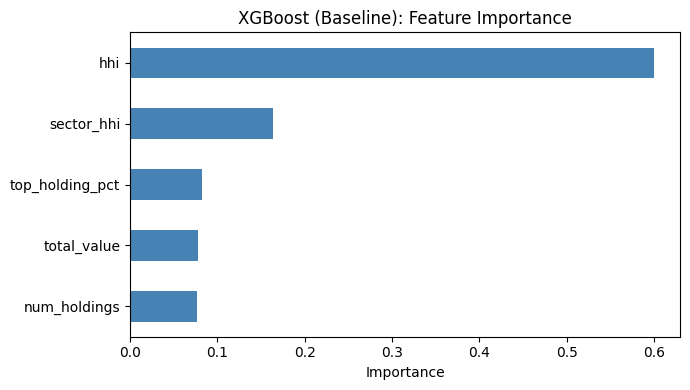

num_holdings       0.076644
total_value        0.078213
top_holding_pct    0.082420
sector_hhi         0.163164
hhi                0.599559
dtype: float32


In [4]:
importances = pd.Series(model2.feature_importances_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
importances.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Importance")
ax.set_title("XGBoost (Baseline): Feature Importance")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "charts", "model2_feature_importance.png"), dpi=100)
plt.show()

print(importances)

              precision    recall  f1-score   support

           0       1.00      0.79      0.88      4979
           1       0.09      0.93      0.17       114

    accuracy                           0.80      5093
   macro avg       0.55      0.86      0.53      5093
weighted avg       0.98      0.80      0.87      5093


Confusion Matrix:
[[3950 1029]
 [   8  106]]

ROC-AUC: 0.926


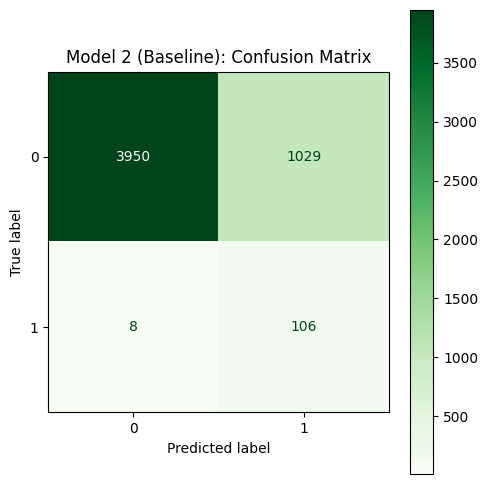

In [5]:
y_pred = model2.predict(X_test)
y_pred_proba = model2.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f'\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred)}')
print(f"\nROC-AUC: {roc_auc_score(y_test, y_pred_proba):.3f}")

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap="Greens")
ax.set_title("Model 2 (Baseline): Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "charts", "model2_confusion_matrix.png"), dpi=100)
plt.show()

## Hyperparameter Tuning Investigation

In [6]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "n_estimators": [50, 100, 200]
}

grid_search = GridSearchCV(
    XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, eval_metric="logloss"),
    param_grid,
    scoring="roc_auc",
    cv=tscv,
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print(f"Best params: {grid_search.best_params_}")
print(f"Best cross-validated ROC-AUC: {grid_search.best_score_:.3f}")

model2 = grid_search.best_estimator_

Best params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
Best cross-validated ROC-AUC: 0.865


In [7]:
importances = pd.Series(model2.feature_importances_, index=feature_cols).sort_values()
print("Feature importance at the grid-search-selected hyperparameters:")
print(importances)

Feature importance at the grid-search-selected hyperparameters:
num_holdings       0.042834
total_value        0.046558
top_holding_pct    0.104090
sector_hhi         0.114021
hhi                0.692497
dtype: float32


              precision    recall  f1-score   support

           0       1.00      0.77      0.87      4979
           1       0.09      0.95      0.16       114

    accuracy                           0.78      5093
   macro avg       0.54      0.86      0.52      5093
weighted avg       0.98      0.78      0.86      5093

ROC-AUC: 0.924

Confusion Matrix:
[[3856 1123]
 [   6  108]]


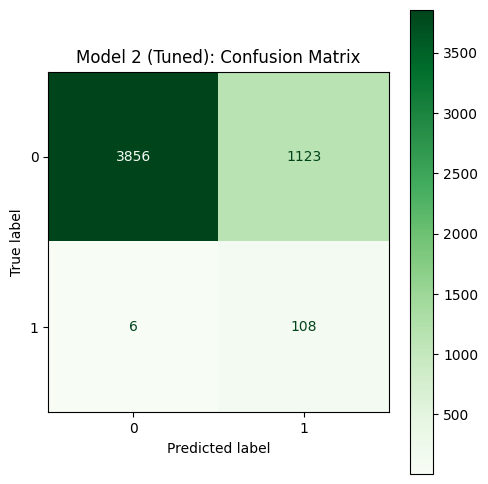

In [8]:
y_pred = model2.predict(X_test)
y_pred_proba = model2.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.3f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap="Greens")
ax.set_title("Model 2 (Tuned): Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "charts", "model2_confusion_matrix.png"), dpi=100)
plt.show()

Hyperparameter tuning via grid search (`TimeSeriesSplit` cross-validation) tested `max_depth`, `learning_rate`, and `n_estimators`, selecting `max_depth=3`, `learning_rate=0.01`, `n_estimators=200` as the cross-validated optimum. On the held-out test set, the tuned model performs essentially identically to the untuned baseline (ROC-AUC 0.924 vs. 0.926, recall 0.95 vs. 0.93), with `hhi`'s dominance as the most important feature strengthening slightly (0.692 vs. 0.600). Unlike Model 1, where tuning produced a substantive, necessary trade-off, this result indicates XGBoost's performance is not highly sensitive to these hyperparameters within the tested range, a genuine finding in itself, consistent with tree-based ensembles' general robustness to the kind of instability seen in Model 1. The tuned model is retained as the final Model 2, since it is not meaningfully worse than the baseline on any metric that matters, and represents the properly validated configuration.

## Final Model Selection

In [9]:
model2 = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.01,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)
model2.fit(X_train, y_train)

print("Final model: XGBClassifier(max_depth=3, learning_rate=0.01, n_estimators=200), fit on the full training set. "
      "This is the locked-in Model 2 used for all downstream evaluation and saving.")

Final model: XGBClassifier(max_depth=3, learning_rate=0.01, n_estimators=200), fit on the full training set. This is the locked-in Model 2 used for all downstream evaluation and saving.


## Feature Importance

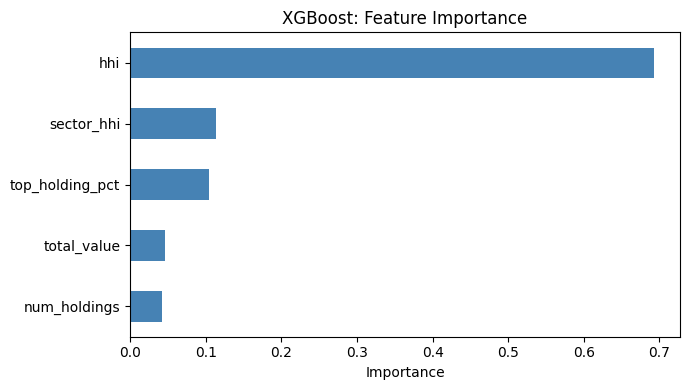

num_holdings       0.042834
total_value        0.046558
top_holding_pct    0.104090
sector_hhi         0.114021
hhi                0.692497
dtype: float32


In [10]:
importances = pd.Series(model2.feature_importances_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
importances.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Importance")
ax.set_title("XGBoost: Feature Importance")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "charts", "model2_feature_importance.png"), dpi=100)
plt.show()

print(importances)

## Evaluate on Test Set

              precision    recall  f1-score   support

           0       1.00      0.77      0.87      4979
           1       0.09      0.95      0.16       114

    accuracy                           0.78      5093
   macro avg       0.54      0.86      0.52      5093
weighted avg       0.98      0.78      0.86      5093


Confusion Matrix:
[[3856 1123]
 [   6  108]]

ROC-AUC: 0.924


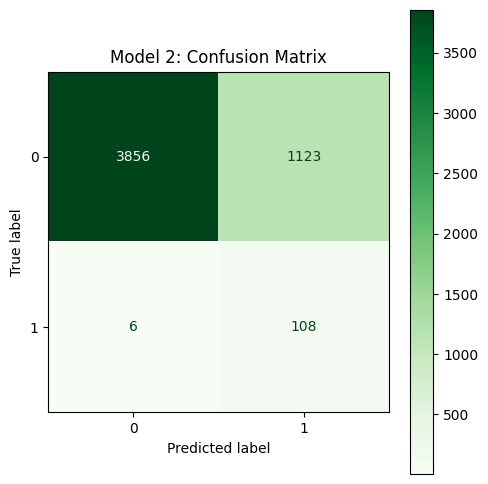

In [11]:
y_pred = model2.predict(X_test)
y_pred_proba = model2.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f'\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred)}')
print(f"\nROC-AUC: {roc_auc_score(y_test, y_pred_proba):.3f}")

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap="Greens")
ax.set_title("Model 2: Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "charts", "model2_confusion_matrix.png"), dpi=100)
plt.show()

ROC-AUC (0.924) is essentially equivalent to Model 1's 0.921, indicating the two models rank risk with comparable strength despite XGBoost's added complexity. Recall on the positive class (0.95) is higher than Model 1's 0.78, at the cost of lower precision (0.09 vs. 0.13) and more false positives, both consequences of `scale_pos_weight` compensating for the same class imbalance that `class_weight="balanced"` addresses in Model 1.

## Save Model

In [12]:
joblib.dump(model2, os.path.join(ARTIFACTS_DIR, "model2_xgboost.pkl"))
print("Model 2 saved.")

Model 2 saved.


## Model Comparison Chart

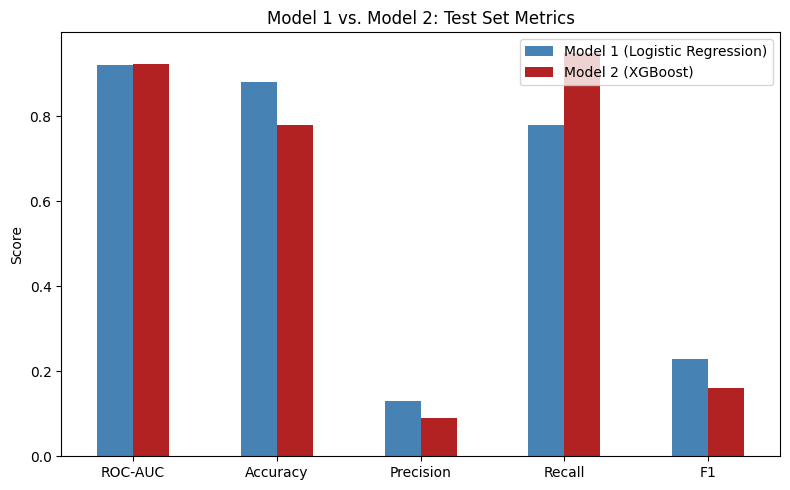

In [13]:
comparison_metrics = pd.DataFrame({
    "Model 1 (Logistic Regression)": [0.921, 0.88, 0.13, 0.78, 0.23],
    "Model 2 (XGBoost)": [0.924, 0.78, 0.09, 0.95, 0.16]
}, index=["ROC-AUC", "Accuracy", "Precision", "Recall", "F1"])

fig, ax = plt.subplots(figsize=(8, 5))
comparison_metrics.plot(kind="bar", ax=ax, color=["steelblue", "firebrick"])
ax.set_ylabel("Score")
ax.set_title("Model 1 vs. Model 2: Test Set Metrics")
ax.legend(loc="upper right")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "charts", "model_comparison.png"), dpi=100)
plt.show()